Saving raw_40_sessions.zip to raw_40_sessions (1).zip
    APSSDC ML MILESTONE PROJECT
 STUDENT CERTIFICATION CLASSIFICATION
File Uploaded: raw_40_sessions (1).zip
ZIP Extracted Successfully
Total Files Found: 40
All Sessions Loaded Successfully
Total Records       : 35777
Columns Detected    : ['name (original name)', 'email', 'join time', 'leave time', 'duration (minutes)', 'session duration', 'session_number']
Identity Column     : email
Duration Column     : duration (minutes)
Session Duration from column: 125 mins
After Merging Duplicates Shape : (30200, 3)
Zoom Reconnect Duplicates Handled Successfully
Session Duration    : 125 mins
Threshold (80%)     : 100 mins
Preprocessing Completed Successfully
Total Sessions      : 40
Certified Students     : 537
Not Certified Students : 218

Bar Chart Representation


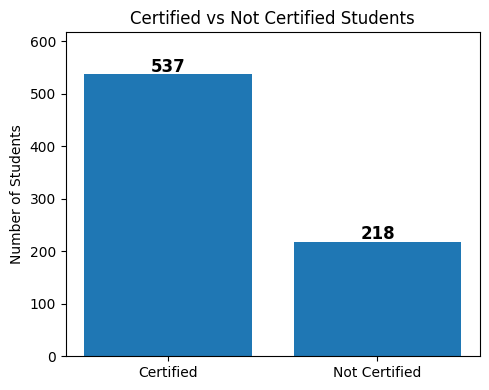


Scatter Plot Representation


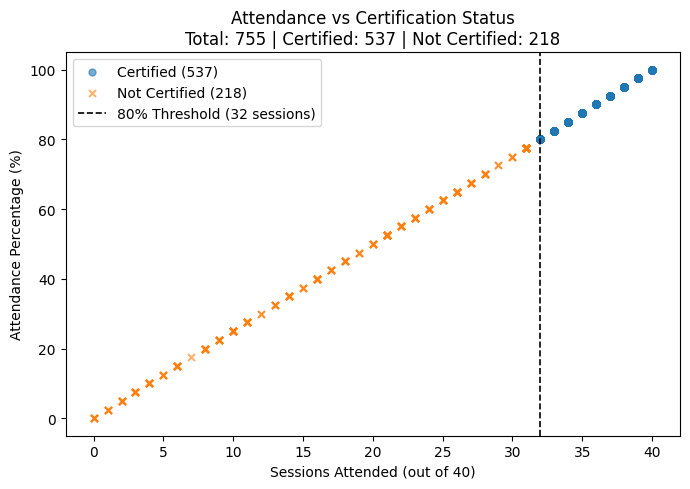


         FINAL PROJECT SUMMARY
Total Students         : 755
Total Sessions         : 40
---------------------------------------------
Certified Students     : 537
Not Certified Students : 218
---------------------------------------------
Certification Rate     : 71 %
Not Certification Rate : 29 %
---------------------------------------------
Random Forest Accuracy : 90 %

     STUDENT ATTENDANCE LOOKUP

Enter Student Email ID (or 'exit' to quit): srujanasreekandadi@gmail.com
       STUDENT ATTENDANCE REPORT
  Email              : srujanasreekandadi@gmail.com
  Total Sessions     : 40
  Sessions Attended  : 9
  Sessions Absent    : 31
  Attendance %       : 22.5%
  Certification      : Not Certified ✗

Enter Student Email ID (or 'exit' to quit): exit
Thank you!


In [ ]:
# ====================================================
# APSSDC ML MILESTONE PROJECT
# STUDENT CERTIFICATION CLASSIFICATION
# ====================================================

# Import Libraries
import pandas as pd
import zipfile
import os
import shutil
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ====================================================
# STEP 1: Upload Any File (ZIP, CSV, Excel)
# ====================================================

uploaded = files.upload()
filename = list(uploaded.keys())[0]

print("=" * 45)
print("    APSSDC ML MILESTONE PROJECT")
print(" STUDENT CERTIFICATION CLASSIFICATION")
print("=" * 45)
print(f"File Uploaded: {filename}")

# ====================================================
# STEP 2: Read File — ZIP / CSV / Excel
# ====================================================

all_data = []

# ── ZIP file ──
if filename.endswith('.zip'):

    # Clear old extracted files to avoid mixing old and new sessions
    if os.path.exists('sessions'):
        shutil.rmtree('sessions')
    os.makedirs('sessions')

    with zipfile.ZipFile(filename, 'r') as z:
        z.extractall('sessions')
    print("ZIP Extracted Successfully")

    csv_files = sorted([
        f for f in os.listdir('sessions')
        if f.endswith('.csv') or f.endswith('.xlsx')
    ])
    print(f"Total Files Found: {len(csv_files)}")

    for i, f in enumerate(csv_files, start=1):
        path = f'sessions/{f}'
        df   = pd.read_excel(path) if f.endswith('.xlsx') else pd.read_csv(path)
        df['session_number'] = i
        all_data.append(df)

# ── Single Excel file ──
elif filename.endswith('.xlsx') or filename.endswith('.xls'):
    df = pd.read_excel(filename)
    df['session_number'] = 1
    all_data.append(df)
    print("Excel File Loaded Successfully")

# ── Single CSV file ──
elif filename.endswith('.csv'):
    df = pd.read_csv(filename)
    df['session_number'] = 1
    all_data.append(df)
    print("CSV File Loaded Successfully")

print("All Sessions Loaded Successfully")

# ====================================================
# STEP 3: Combine All Sessions
# ====================================================

combined = pd.concat(all_data, ignore_index=True)

# Clean column names
combined.columns = combined.columns.str.lower().str.strip()

print(f"Total Records       : {len(combined)}")
print(f"Columns Detected    : {list(combined.columns)}")

# ====================================================
# STEP 3B: Auto Detect Key Columns
# ====================================================

# Remove host rows if zoom file
if 'guest' in combined.columns:
    combined = combined[combined['guest'] == 'Yes'].copy()
    print("Zoom file detected — Host rows removed")

# If multiple topics exist — keep topic with most students
if 'topic' in combined.columns:
    topics = combined['topic'].unique()
    print("Topics found:")
    for i, t in enumerate(topics):
        print(f"  {i+1}. {t}")
    main_topic = combined['topic'].value_counts().idxmax()
    combined   = combined[combined['topic'] == main_topic].copy()
    print(f"Using topic: {main_topic}")

# Auto detect email/id column — skip host columns
id_col = None
for col in combined.columns:
    if col == 'email':
        id_col = col
        break
if id_col is None:
    for col in combined.columns:
        if 'email' in col and 'host' not in col:
            id_col = col
            break
if id_col is None:
    for col in combined.columns:
        if 'id' in col and 'host' not in col:
            id_col = col
            break

# Auto detect duration column
# Zoom files use 'duration (minutes).1' for student duration
# Generated files use 'total_duration'
dur_col = None
for col in combined.columns:
    if 'duration' in col and '.1' in col:
        dur_col = col
        break
if dur_col is None:
    for col in combined.columns:
        if 'total' in col and 'duration' in col:
            dur_col = col
            break
if dur_col is None:
    for col in combined.columns:
        if 'duration' in col and 'session' not in col and 'total participant' not in col:
            dur_col = col
            break

print(f"Identity Column     : {id_col}")
print(f"Duration Column     : {dur_col}")

# ====================================================
# STEP 3C: Handle Zoom Reconnect / Duplicates
# ====================================================

# Auto detect session duration safely
SESSION_DURATION = None

# Check for session duration column
for col in combined.columns:
    if 'session' in col and 'duration' in col:
        val = combined[col].dropna()
        if len(val) > 0:
            SESSION_DURATION = int(val.iloc[0])
            print(f"Session Duration from column: {SESSION_DURATION} mins")
            break

# For zoom files — read from meeting duration column
if SESSION_DURATION is None:
    for col in combined.columns:
        if col == 'duration (minutes)':
            val = combined[col].dropna()
            if len(val) > 0:
                SESSION_DURATION = int(val.iloc[0])
                print(f"Session Duration from meeting: {SESSION_DURATION} mins")
            break

# Final fallback
if SESSION_DURATION is None:
    SESSION_DURATION = 120
    print(f"Using default Session Duration: {SESSION_DURATION} mins")

# Merge duplicate rows — zoom drop/rejoin (sum duration per student per session)
combined = combined.groupby(
    [id_col, 'session_number'], as_index=False
)[dur_col].sum()

print(f"After Merging Duplicates Shape : {combined.shape}")
print("Zoom Reconnect Duplicates Handled Successfully")

# ====================================================
# STEP 4: Preprocessing
# ====================================================

# Fill missing values with 0
combined[dur_col] = combined[dur_col].fillna(0)

# 80% of session duration = minimum to mark Present
THRESHOLD = SESSION_DURATION * 0.80

print(f"Session Duration    : {SESSION_DURATION} mins")
print(f"Threshold (80%)     : {int(THRESHOLD)} mins")

# Mark Present or Absent based on duration
combined['attendance'] = combined[dur_col].apply(
    lambda x: 'Present' if x >= THRESHOLD else 'Absent'
)

print("Preprocessing Completed Successfully")

# ====================================================
# STEP 5: Count Sessions Attended Per Student
# ====================================================

total_sessions = combined['session_number'].nunique()
print(f"Total Sessions      : {total_sessions}")

summary = combined.groupby(id_col)['attendance'].apply(
    lambda x: (x == 'Present').sum(),
    include_groups=False
).reset_index()

summary.columns = [id_col, 'sessions_attended']

# Attendance percentage
summary['attendance_pct'] = (
    summary['sessions_attended'] / total_sessions * 100
).round(2)

# ====================================================
# STEP 6: Certification Status
# ====================================================

# 80% of total sessions = minimum sessions to get certified
min_sessions = total_sessions * 0.80

summary['certified'] = (
    summary['sessions_attended'] >= min_sessions
).astype(int)

certified     = (summary['certified'] == 1).sum()
not_certified = (summary['certified'] == 0).sum()

print(f"Certified Students     : {certified}")
print(f"Not Certified Students : {not_certified}")

# ====================================================
# STEP 7: Random Forest Model
# ====================================================

# Pivot: 1 row per student, each session = 1 column
# 1 = Present, 0 = Absent
combined['present'] = (combined['attendance'] == 'Present').astype(int)

pivot = combined.pivot_table(
    index=id_col,
    columns='session_number',
    values='present',
    fill_value=0
).reset_index()

pivot.columns = [id_col] + [f'S{i}' for i in range(1, total_sessions + 1)]

final_df = pivot.merge(summary, on=id_col)

# X = attendance in each session (input)
# y = certified or not (output)
X = final_df[[f'S{i}' for i in range(1, total_sessions + 1)]]
y = final_df['certified']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# ====================================================
# STEP 8: Bar Chart
# ====================================================

print("\nBar Chart Representation")

plt.figure(figsize=(5, 4))

bars = plt.bar(
    ['Certified', 'Not Certified'],
    [certified, not_certified]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(int(bar.get_height())),
        ha='center', fontsize=12, fontweight='bold'
    )

plt.title('Certified vs Not Certified Students')
plt.ylabel('Number of Students')
plt.ylim(0, max(certified, not_certified) + 80)
plt.tight_layout()
plt.savefig('bar_chart.png', dpi=150)
plt.show()

# ====================================================
# STEP 9: Scatter Plot
# ====================================================

print("\nScatter Plot Representation")

fig, ax = plt.subplots(figsize=(7, 5))

certified_students     = summary[summary['certified'] == 1]
not_certified_students = summary[summary['certified'] == 0]

ax.scatter(
    certified_students['sessions_attended'],
    certified_students['attendance_pct'],
    marker='o',
    label=f'Certified ({len(certified_students)})',
    alpha=0.6, s=25
)

ax.scatter(
    not_certified_students['sessions_attended'],
    not_certified_students['attendance_pct'],
    marker='x',
    label=f'Not Certified ({len(not_certified_students)})',
    alpha=0.6, s=25
)

ax.axvline(
    x=min_sessions,
    color='black', linestyle='--', linewidth=1.2,
    label=f'80% Threshold ({int(min_sessions)} sessions)'
)

ax.set_xlabel(f'Sessions Attended (out of {total_sessions})')
ax.set_ylabel('Attendance Percentage (%)')
ax.set_title(
    f'Attendance vs Certification Status\n'
    f'Total: {len(summary)} | Certified: {certified} | Not Certified: {not_certified}'
)
ax.legend()
plt.tight_layout()
plt.savefig('scatter_plot.png', dpi=150)
plt.show()

# ====================================================
# STEP 10: Final Summary
# ====================================================

print("\n" + "=" * 45)
print("         FINAL PROJECT SUMMARY")
print("=" * 45)
print("Total Students         :", len(summary))
print("Total Sessions         :", total_sessions)
print("-" * 45)
print("Certified Students     :", certified)
print("Not Certified Students :", not_certified)
print("-" * 45)
print("Certification Rate     :", round(certified / len(summary) * 100), "%")
print("Not Certification Rate :", round(not_certified / len(summary) * 100), "%")
print("-" * 45)
print("Random Forest Accuracy :", round(accuracy * 100), "%")
print("=" * 45)


# ====================================================
# STEP 11: Student Attendance Lookup
# ====================================================

print("\n" + "=" * 45)
print("     STUDENT ATTENDANCE LOOKUP")
print("=" * 45)

while True:

    email = input("\nEnter Student Email ID (or 'exit' to quit): ").strip().lower()

    if email == 'exit':
        print("Thank you!")
        break

    # Check if email exists
    student = summary[summary[id_col].str.lower() == email]

    if len(student) == 0:
        print("=" * 45)
        print("  Email Not Found!")
        print("  Please Enter Correct Email ID")
        print("=" * 45)

    else:
        row = student.iloc[0]

        sessions_attended = int(row['sessions_attended'])
        sessions_absent   = total_sessions - sessions_attended
        attendance_pct    = round(row['attendance_pct'], 2)
        cert_status       = "Certified ✓" if row['certified'] == 1 else "Not Certified ✗"

        print("=" * 45)
        print("       STUDENT ATTENDANCE REPORT")
        print("=" * 45)
        print(f"  Email              : {row[id_col]}")
        print(f"  Total Sessions     : {total_sessions}")
        print(f"  Sessions Attended  : {sessions_attended}")
        print(f"  Sessions Absent    : {sessions_absent}")
        print(f"  Attendance %       : {attendance_pct}%")
        print(f"  Certification      : {cert_status}")
        print("=" * 45)